In [ ]:
# import gdown, zipfile
# url = 'https://drive.google.com/file/d/1xEOrywb5y_P8JedxeN0ICsASs2zzDgdV/view?usp=sharing'
# path = gdown.download(url, quiet=False, fuzzy=True)
# with zipfile.ZipFile(path, 'r') as f: f.extractall('data')

Downloading...
From (original): https://drive.google.com/uc?id=1xEOrywb5y_P8JedxeN0ICsASs2zzDgdV
From (redirected): https://drive.google.com/uc?id=1xEOrywb5y_P8JedxeN0ICsASs2zzDgdV&confirm=t&uuid=4a1f3314-6ed7-40be-b1fa-731499d4db29
To: /kaggle/working/ml-latest.zip
100%|██████████| 351M/351M [00:11<00:00, 31.5MB/s] 


In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder
from collections import defaultdict
import warnings

warnings.filterwarnings('ignore')
pl.seed_everything(42)

DATA_DIR = 'data/ml-small/'

W0404 10:15:08.099000 21540 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels
Seed set to 42


### Часть 1. Подготовка данных и реализация SVD (PyTorch)
Загрузим данные и подготовим их. Нам нужно закодировать ID пользователей и фильмов в непрерывные индексы от 0 до N-1, чтобы использовать их в качестве индексов для слоев `nn.Embedding`.

In [2]:
ratings_path = os.path.join(DATA_DIR, 'ratings.csv')
movies_path = os.path.join(DATA_DIR, 'movies.csv')

ratings = pd.read_csv(ratings_path)
movies = pd.read_csv(movies_path)

# 1. Собираем ВСЕ возможные ID, чтобы энкодеры знали всё
all_users = ratings['userId'].unique()
# Объединяем movieId из обоих файлов на случай нестыковок
all_movies = pd.concat([movies['movieId'], ratings['movieId']]).unique()

user_encoder = LabelEncoder()
movie_encoder = LabelEncoder()

user_encoder.fit(all_users)
movie_encoder.fit(all_movies)

# 2. Трансформируем данные
ratings['user_idx'] = user_encoder.transform(ratings['userId'])
ratings['movie_idx'] = movie_encoder.transform(ratings['movieId'])
movies['movie_idx'] = movie_encoder.transform(movies['movieId'])

# 3. Определяем размеры для слоев Embedding
# Берем len(classes_), чтобы точно вместить все индексы
num_users = len(user_encoder.classes_)
num_movies = len(movie_encoder.classes_)
global_mean = ratings['rating'].mean()

print(f"Размер словаря пользователей: {num_users}")
print(f"Размер словаря фильмов: {num_movies}")

# 4. Train/Test split
train_df, test_df = train_test_split(ratings, test_size=0.2, random_state=42)

class MovieLensDataset(Dataset):
    def __init__(self, df: pd.DataFrame):
        self.users = torch.tensor(df['user_idx'].values, dtype=torch.long)
        self.movies = torch.tensor(df['movie_idx'].values, dtype=torch.long)
        self.ratings = torch.tensor(df['rating'].values, dtype=torch.float32)

    def __len__(self): return len(self.ratings)
    def __getitem__(self, idx): return self.users[idx], self.movies[idx], self.ratings[idx]

train_loader = DataLoader(MovieLensDataset(train_df), batch_size=1024, shuffle=True)
val_loader = DataLoader(MovieLensDataset(test_df), batch_size=1024, shuffle=False)

Размер словаря пользователей: 610
Размер словаря фильмов: 9742


Опишем модель коллаборативной фильтрации на PyTorch Lightning. Это эквивалент алгоритма SVD, только мы находим матрицу разложения с помощью стохастического градиентного спуска (Adam).

In [3]:
class SVDModel(pl.LightningModule):
    def __init__(self, num_users, num_items, embed_dim=100, global_mean=3.5, lr=0.005, weight_decay=1e-5):
        super().__init__()
        self.save_hyperparameters()
        self.global_mean = global_mean
        
        # Эмбеддинги (скрытые факторы p_u и q_i)
        # [Num_Users, Embed_Dim]
        self.user_embedding = nn.Embedding(num_users, embed_dim)
        # [Num_Items, Embed_Dim]
        self.item_embedding = nn.Embedding(num_items, embed_dim)
        
        # Смещения (biases)
        # [Num_Users, 1]
        self.user_bias = nn.Embedding(num_users, 1)
        # [Num_Items, 1]
        self.item_bias = nn.Embedding(num_items, 1)
        
        # Инициализация весов
        nn.init.normal_(self.user_embedding.weight, std=0.01)
        nn.init.normal_(self.item_embedding.weight, std=0.01)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.item_bias.weight)
        
        self.loss_fn = nn.MSELoss()

    def forward(self, users, items):
        # 1. Достаем векторы: [Batch, Embed_Dim]
        user_vecs = self.user_embedding(users)
        item_vecs = self.item_embedding(items)
        
        # 2. Скалярное произведение (Dot Product): [Batch]
        dot_product = (user_vecs * item_vecs).sum(dim=1)
        
        # 3. Достаем смещения:[Batch]
        u_bias = self.user_bias(users).squeeze()
        i_bias = self.item_bias(items).squeeze()
        
        # 4. Формула прогноза
        prediction = self.global_mean + u_bias + i_bias + dot_product
        return prediction

    def training_step(self, batch, batch_idx):
        users, items, ratings = batch
        preds = self(users, items)
        loss = self.loss_fn(preds, ratings)
        self.log('train_loss', loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        users, items, ratings = batch
        preds = self(users, items)
        loss = self.loss_fn(preds, ratings)
        # Извлекаем корень из MSE, чтобы получить RMSE
        rmse = torch.sqrt(loss)
        self.log('val_rmse', rmse, prog_bar=True)
        return rmse

    def configure_optimizers(self):
        # L2-регуляризация вшита в weight_decay
        optimizer = torch.optim.Adam(self.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.weight_decay)
        return optimizer
model_svd = SVDModel(
    num_users=num_users, 
    num_items=num_movies, 
    embed_dim=50, 
    global_mean=global_mean
)

early_stop_callback = EarlyStopping(monitor="val_rmse", patience=3, mode="min")

trainer = pl.Trainer(
    max_epochs=1,
    callbacks=[early_stop_callback],
    accelerator="auto"
)

trainer.fit(model_svd, train_loader, val_loader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
You are using a CUDA device ('NVIDIA GeForce RTX 5070 Ti Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name           ┃ Type      ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ user_embedding │ Embedding │ 30.5 K │ train │     0 │
│ 1 │ item_embedding │ Embedding │  487 K │ train │     0 │
│ 2 │ user_bias      │ Embedding │    610 │ train │     0 │
│ 3 │ item_bias      │ Embedding │  9.7 K │ train │     0 │
│ 4 │ loss_fn        │ MSELoss   │      0 │ train │     0 │
└───┴────────────────┴───────────┴────────┴───────┴───────┘

Trainable params: 527 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 527 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 5                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=1` reached.


### Оценка модели (Реализация метрик Precision, Recall, NDCG)
Классические метрики в задачах ранжирования требуют группировки предсказаний по пользователям. Мы предсказываем оценки, сортируем их и смотрим попадают ли реально понравившиеся фильмы в топ-K наших рекомендаций.

In [4]:
def get_top_n_predictions(model, df, n=10, threshold=3.5):
    """Предсказывает оценки для тестового датасета и возвращает Top-N для каждого юзера"""
    model.eval()
    user_preds = defaultdict(list)
    
    with torch.no_grad():
        users_t = torch.tensor(df['user_idx'].values, dtype=torch.long)
        movies_t = torch.tensor(df['movie_idx'].values, dtype=torch.long)
        ratings_true = df['rating'].values
        
        preds = model(users_t, movies_t).numpy()
        
    for uid, iid, true_r, est_r in zip(df['user_idx'].values, df['movie_idx'].values, ratings_true, preds):
        user_preds[uid].append((iid, true_r, est_r))
        
    # Сортируем прогнозы по убыванию оценки
    for uid, user_ratings in user_preds.items():
        user_ratings.sort(key=lambda x: x[2], reverse=True)
        user_preds[uid] = user_ratings[:n]
        
    return user_preds

def evaluate_ranking_metrics(user_preds, threshold=3.5):
    precisions, recalls, ndcgs = dict(), dict(), dict()
    
    for uid, user_ratings in user_preds.items():
        # Релевантные айтемы (оценка >= threshold)
        n_rel = sum((true_r >= threshold) for (_, true_r, _) in user_ratings)
        n_rec_k = len(user_ratings)
        n_rel_and_rec_k = sum(((true_r >= threshold) and (est >= threshold)) for (_, true_r, est) in user_ratings)
        
        # Precision@K: Доля релевантных среди рекомендованных
        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0
        # Recall@K: Доля рекомендованных среди всех релевантных
        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0
        
        # NDCG@K
        dcg = 0
        idcg = 0
        # Сортируем истинные рейтинги по убыванию для IDCG
        ideal_ratings = sorted([true_r for (_, true_r, _) in user_ratings], reverse=True)
        
        for i, (_, true_r, est) in enumerate(user_ratings):
            if true_r >= threshold: # Упрощенная релевантность
                dcg += 1 / np.log2(i + 2) # i+2 т.к. индексы с 0, а логарифм нужен по основанию 2 от позиции (с 1)
            if ideal_ratings[i] >= threshold:
                idcg += 1 / np.log2(i + 2)
                
        ndcgs[uid] = dcg / idcg if idcg > 0 else 0
        
    return {
        "Precision@10": np.mean(list(precisions.values())),
        "Recall@10": np.mean(list(recalls.values())),
        "NDCG@10": np.mean(list(ndcgs.values()))
    }

top_n_svd = get_top_n_predictions(model_svd, test_df, n=10)
svd_metrics = evaluate_ranking_metrics(top_n_svd)
print("SVD Model Metrics:")
for k, v in svd_metrics.items():
    print(f"{k}: {v:.4f}")

SVD Model Metrics:
Precision@10: 0.6580
Recall@10: 0.8437
NDCG@10: 0.9043


### Часть 2 и 3. Контентная фильтрация (TF-IDF) и Гибридная модель
Теперь мы извлечем жанры из `movies.csv`, построим TF-IDF векторы и матрицу косинусного сходства. Гибридная модель будет объединять предсказания SVD (CF) и предсказания на основе контента (CBF).

In [5]:
from sklearn.preprocessing import normalize

# Чистим жанры и готовим TF-IDF
movies['genres_clean'] = movies['genres'].str.replace('|', ' ', regex=False).fillna('Unknown')
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(movies['genres_clean'])
tfidf_matrix = normalize(tfidf_matrix, axis=1)

# Создаем быстрый маппинг: movie_idx -> позиция в строке movies (и в tfidf_matrix)
idx_to_matrix_pos = {idx: pos for pos, idx in enumerate(movies['movie_idx'].values)}

def get_cbf_prediction_safe(user_idx, target_movie_idx, train_df, tfidf_sparse):
    user_history = train_df[train_df['user_idx'] == user_idx]
    if user_history.empty: return global_mean
    
    target_pos = idx_to_matrix_pos.get(target_movie_idx)
    if target_pos is None: return global_mean
    
    # Собираем позиции в матрице для истории оценок пользователя
    hist_movie_indices = user_history['movie_idx'].values
    hist_positions = [idx_to_matrix_pos[idx] for idx in hist_movie_indices if idx in idx_to_matrix_pos]
    
    if not hist_positions: return global_mean
    
    # Сходство через скалярное произведение разреженных матриц
    target_vec = tfidf_sparse[target_pos]
    history_vecs = tfidf_sparse[hist_positions]
    similarities = (target_vec @ history_vecs.T).toarray().ravel()
    
    # Взвешенное среднее по всем оценкам (или топ-K)
    ratings_history = user_history['rating'].values[:len(similarities)] # на случай нестыковки длин
    
    weights = similarities
    if weights.sum() == 0: return user_history['rating'].mean()
    
    return np.dot(weights, ratings_history) / weights.sum()

# --- EVALUATION ---
def evaluate_hybrid_final(test_df, train_df, model, tfidf_m, alpha=0.7):
    model.eval()
    # На большом датасете 1000 семплов достаточно для оценки
    subset = test_df.sample(n=min(1000, len(test_df)), random_state=42)
    
    u_idx = torch.tensor(subset['user_idx'].values, dtype=torch.long)
    m_idx = torch.tensor(subset['movie_idx'].values, dtype=torch.long)
    
    with torch.no_grad():
        svd_preds = model(u_idx, m_idx).cpu().numpy()
    
    results = []
    print("Computing CBF for test subset...")
    for i, (idx, row) in enumerate(subset.iterrows()):
        u, m, true_r = int(row['user_idx']), int(row['movie_idx']), row['rating']
        
        cbf_p = get_cbf_prediction_safe(u, m, train_df, tfidf_m)
        hybrid_p = alpha * svd_preds[i] + (1 - alpha) * cbf_p
        
        results.append((true_r, svd_preds[i], cbf_p, hybrid_p))
    
    return results

# Запуск
raw_results = evaluate_hybrid_final(test_df, train_df, model_svd, tfidf_matrix)

# Расчет метрик
y_true = [x[0] for x in raw_results]
y_svd = [x[1] for x in raw_results]
y_cbf = [x[2] for x in raw_results]
y_hybrid = [x[3] for x in raw_results]

def rmse(a, b): return np.sqrt(np.mean((np.array(a)-np.array(b))**2))

print(f"\nFinal RMSE (SVD): {rmse(y_true, y_svd):.4f}")
print(f"Final RMSE (CBF): {rmse(y_true, y_cbf):.4f}")
print(f"Final RMSE (Hybrid): {rmse(y_true, y_hybrid):.4f}")

Computing CBF for test subset...

Final RMSE (SVD): 0.9313
Final RMSE (CBF): 0.9314
Final RMSE (Hybrid): 0.9120


Сравнение SVD и Гибридной модели (на случайных примерах):


,Movie Title,Genres,True,SVD Pred,Content Pred,Hybrid Pred,SVD Error,Hybrid Error
0,Meet the Fockers (2004),Comedy,4.0,3.64,3.98,3.74,0.36,0.26
1,Apocalypse Now (1979),Action|Drama|War,5.0,4.16,3.51,3.96,0.84,1.04
2,Alien (1979),Horror|Sci-Fi,4.0,3.91,3.27,3.72,0.09,0.28
3,Toy Story 3 (2010),Adventure|Animation|,4.0,3.76,3.52,3.69,0.24,0.31
4,"Lord of the Rings, The (1978)",Adventure|Animation|,5.0,3.70,4.39,3.91,1.30,1.09
5,Alive (1993),Drama,3.0,3.51,4.21,3.72,0.51,0.72
6,For Your Eyes Only (1981),Action|Adventure|Thr,5.0,3.55,3.46,3.52,1.45,1.48
7,"Lock, Stock & Two Smoking Barrels (1998)",Comedy|Crime|Thrille,4.5,3.83,3.64,3.78,0.67,0.72
8,"Incredibles, The (2004)",Action|Adventure|Ani,3.0,3.60,2.97,3.41,0.60,0.41
9,The Shape of Water (2017),Adventure|Drama|Fant,3.5,3.47,3.32,3.43,0.03,0.07


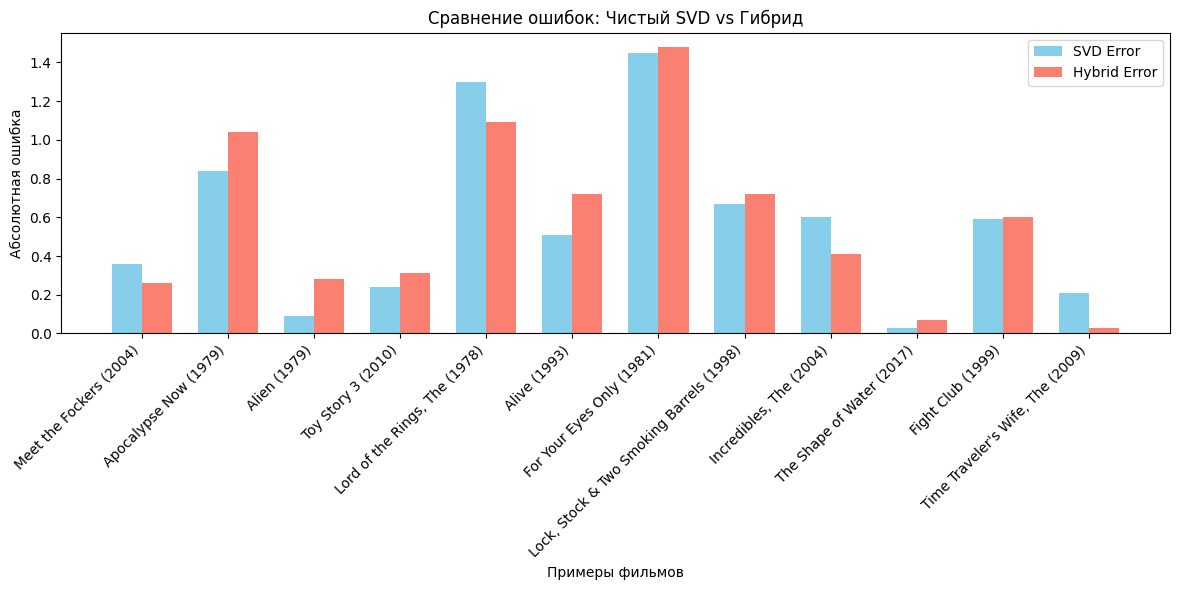

In [7]:
import matplotlib.pyplot as plt

def show_svd_prediction_examples(test_df, movies_df, model, tfidf_m, n_examples=10, alpha=0.7):
    """
    Примеры предсказаний для модели SVD и Гибрида.
    """
    model.eval() # Переводим SVD в режим оценки
    
    # Берем случайные примеры
    samples = test_df.sample(n_examples, random_state=42)
    
    example_results = []
    
    for _, row in samples.iterrows():
        u_idx = int(row['user_idx'])
        m_idx = int(row['movie_idx'])
        true_r = row['rating']
        
        # 1. Получаем название и жанры
        movie_info = movies_df[movies_df['movie_idx'] == m_idx]
        title = movie_info['title'].values[0]
        genres = movie_info['genres'].values[0]
        
        # 2. Прогноз SVD (PyTorch)
        # Нам нужно передать тензоры в модель
        u_tensor = torch.tensor([u_idx], dtype=torch.long)
        m_tensor = torch.tensor([m_idx], dtype=torch.long)
        
        with torch.no_grad():
            p_svd = model(u_tensor, m_tensor).item()
        
        # 3. Прогноз Content (наша safe функция из ячейки 5)
        p_content = get_cbf_prediction_safe(u_idx, m_idx, train_df, tfidf_m)
        
        # 4. Гибридный прогноз
        p_hybrid = alpha * p_svd + (1 - alpha) * p_content
        
        example_results.append({
            'Movie Title': title[:40],
            'Genres': genres[:20],
            'True': true_r,
            'SVD Pred': round(p_svd, 2),
            'Content Pred': round(p_content, 2),
            'Hybrid Pred': round(p_hybrid, 2),
            'SVD Error': round(abs(true_r - p_svd), 2),
            'Hybrid Error': round(abs(true_r - p_hybrid), 2)
        })
        
    df_res = pd.DataFrame(example_results)
    return df_res

# Запуск
svd_examples = show_svd_prediction_examples(test_df, movies, model_svd, tfidf_matrix, n_examples=12)
print("Сравнение SVD и Гибридной модели (на случайных примерах):")
display(svd_examples)

# Визуализация сравнения ошибок
plt.figure(figsize=(12, 6))
x = np.arange(len(svd_examples))
width = 0.35

plt.bar(x - width/2, svd_examples['SVD Error'], width, label='SVD Error', color='skyblue')
plt.bar(x + width/2, svd_examples['Hybrid Error'], width, label='Hybrid Error', color='salmon')

plt.xlabel('Примеры фильмов')
plt.ylabel('Абсолютная ошибка')
plt.title('Сравнение ошибок: Чистый SVD vs Гибрид')
plt.xticks(x, svd_examples['Movie Title'], rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()